In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
import logging
from pathlib import Path

import numpy as np
import xarray as xr

logger = logging.getLogger('disp_xr')

# Configure basic logging
logger.setLevel(logging.INFO)  # Set logging level

# Create handler (console output)
handler = logging.StreamHandler()
handler.setLevel(logging.INFO)  # Set level for this handler

# Add handler to logger
logger.addHandler(handler)

# Prevent duplicate logs if the root logger already has handlers
logger.propagate = False
work_dir = Path('/u/aurora-r0/staniewi/dev/disp-production-data/australia/')

In [18]:
ds_path = work_dir /'F43655/ncs'
output_dir = Path('/u/aurora-r0/govorcin/01_OPERA/STAKEHOLDER/AUSTRALIA/perth')
output_dir.mkdir(exist_ok=True)

In [19]:
ds = xr.open_dataset(output_dir / 'perth_displacement.zarr', chunks={})

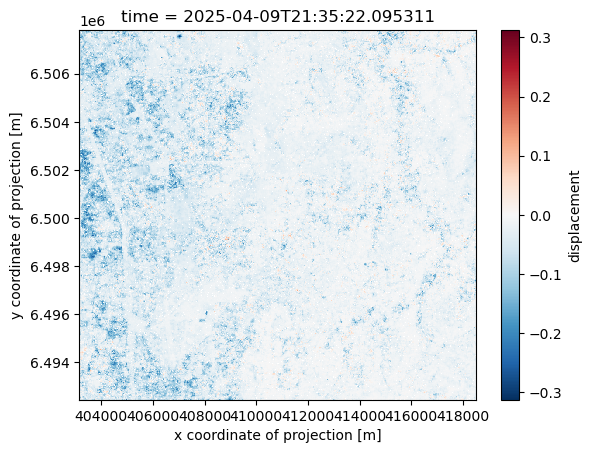

In [20]:
from disp_xr.utils import get_chunks_indices

chunk_ix = get_chunks_indices(ds)
subset = ds.displacement[chunk_ix[50]]
subset.isel(time=-1).plot.imshow()

In [21]:
from disp_xr.timeseries import (
    compute_statistics_numpy,
    create_design_matrix,
    get_coefficient_names,
)

In [22]:
fitting_kwargs = {'polynomial_degree': 1,
    'periods': [1, 0.5],
    'step_dates': None,
    'exponential_terms':  None,
    'logarithmic_terms':  None}

A = create_design_matrix(ds.time.values, **fitting_kwargs)

In [23]:
get_coefficient_names(**fitting_kwargs)

['constant',
 'linear_trend',
 'annual_sin',
 'annual_cos',
 'semiannual_sin',
 'semiannual_cos']

In [24]:
from disp_xr.timeseries import _jax_solver, lscov_2d

In [25]:
n_time, n_height, n_width = subset.shape
n_params = A.shape[1]
n_pixels = n_height * n_width
data_2d = subset.values.reshape(n_time, n_pixels, order='C')

In [34]:
%%time
r = lscov_2d(A, data_2d, full_stats=False)

CPU times: user 22.9 s, sys: 3.62 s, total: 26.6 s
Wall time: 1.2 s


In [64]:
from typing import Dict, List, Optional


def fit_timeseries(
    dxr: xr.DataArray,
    weights: Optional[np.ndarray] = None,
    polynomial_degree: int = 1,
    periods: Optional[List[float]] = None,
    step_dates: Optional[List[str]] = None,
    exponential_terms: Optional[Dict[str, List[int]]] = None,
    logarithmic_terms: Optional[Dict[str, List[int]]] = None,
    reference_index: int = 0,
) -> xr.Dataset:
    """Fit time series data using a specified design matrix and return an xarray.Dataset
    with fitted coefficients and associated statistics.
    """
    # Generate design matrix and coefficient names
    A = create_design_matrix(
        dxr.time.values,
        polynomial_degree,
        periods,
        step_dates,
        exponential_terms,
        logarithmic_terms,
        reference_index
    )
    coeff_names = get_coefficient_names(
        polynomial_degree,
        periods,
        step_dates,
        exponential_terms,
        logarithmic_terms
    )

    # Flatten spatial dimensions
    n_time, n_height, n_width = dxr.shape
    n_params = A.shape[1]
    n_pixels = n_height * n_width
    data_2d = dxr.values.reshape(n_time, n_pixels, order='C')

    # Fit model
    results = lscov_2d(A, data_2d, weights=weights)

        # Build xarray.Dataset
    ds = xr.Dataset(
        {
            "coefficients": (["coefficient", "y", "x"],
                    results.coeffs.reshape(n_params, n_height, n_width)),
            "standard_errors": (["coefficient", "y", "x"],
                    results.standard_errors.reshape(n_params, n_height, n_width)),
            "mse": (["y", "x"], results.mse.reshape(n_height, n_width)),
        },
        coords={
            "y": dxr.y.values if "y" in dxr.dims else np.arange(n_height),
            "x": dxr.x.values if "x" in dxr.dims else np.arange(n_width),
            "coefficient": coeff_names,
        },
        attrs={"description": "Time series fit results with statistical metrics."}
    )

    return ds


def create_fit_template(n_params: int, y: np.array, x: np.array, coeff_names: List[str]) -> xr.Dataset:
    n_height, n_width = y.size, x.size
    return xr.Dataset(
        {
            "coefficients": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "standard_errors": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "mse": (["y", "x"], np.full((n_height, n_width), np.nan)),
        },
        coords={
            "coefficient": coeff_names,
            "y": y,
            "x": x,
        },
        attrs={"description": "Template for time series fit results with statistical metrics."}
    )


In [65]:
fit_timeseries(subset)

<xarray.Dataset> Size: 10MB
Dimensions:          (coefficient: 2, y: 512, x: 512)
Coordinates:
  * y                (y) float64 4kB 6.508e+06 6.508e+06 ... 6.492e+06 6.492e+06
  * x                (x) float64 4kB 4.032e+05 4.032e+05 ... 4.185e+05 4.185e+05
  * coefficient      (coefficient) <U12 96B 'constant' 'linear_trend'
Data variables:
    coefficients     (coefficient, y, x) float64 4MB -0.0172 -0.01817 ... nan
    standard_errors  (coefficient, y, x) float64 4MB 0.002094 0.002328 ... nan
    mse              (y, x) float64 2MB 0.0002859 0.0003533 ... 0.0002194 nan
Attributes:
    description:  Time series fit results with statistical metrics.

In [66]:
fitting_kwargs = {'polynomial_degree': 1,
    'periods': [1, 0.5],
    'step_dates': None,
    'exponential_terms':  None,
    'logarithmic_terms':  None}

names = get_coefficient_names(**fitting_kwargs)
n_time, n_height, n_width = ds.displacement.shape
empty_ds = create_fit_template(len(names), ds.y, ds.x, names)
empty_ds = empty_ds.chunk({'y':ds.chunks['y'], 'x':ds.chunks['x']})

In [67]:
empty_ds

<xarray.Dataset> Size: 8GB
Dimensions:          (coefficient: 6, y: 7697, x: 10054)
Coordinates:
  * y                (y) float64 62kB 6.539e+06 6.538e+06 ... 6.308e+06
  * x                (x) float64 80kB 2.496e+05 2.496e+05 ... 5.511e+05
  * coefficient      (coefficient) <U14 336B 'constant' ... 'semiannual_cos'
Data variables:
    coefficients     (coefficient, y, x) float64 4GB dask.array<chunksize=(6, 512, 512), meta=np.ndarray>
    standard_errors  (coefficient, y, x) float64 4GB dask.array<chunksize=(6, 512, 512), meta=np.ndarray>
    mse              (y, x) float64 619MB dask.array<chunksize=(512, 512), meta=np.ndarray>
Attributes:
    description:  Template for time series fit results with statistical metrics.

In [68]:
out = ds.displacement.map_blocks(fit_timeseries,
                                 kwargs=fitting_kwargs, template=empty_ds)

In [69]:
%%time
out = out.compute()

CPU times: user 15min, sys: 4min 35s, total: 19min 35s
Wall time: 14.3 s


In [74]:
def sincos_to_amplitude_phase(A_cos, A_sin, period=12):
    amplitude = np.sqrt(A_cos**2 + A_sin**2)
    phase = (period / (2 * np.pi)) * np.arctan2(-A_sin, A_cos)
    return amplitude, phase % period

In [84]:
amp, phase = sincos_to_amplitude_phase(out.coefficients[3],
                                       out.coefficients[2])
phase_wrapped = np.mod(phase, 2 * np.pi)

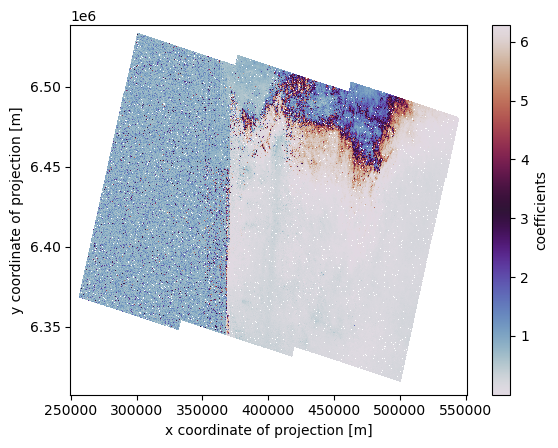

In [86]:
phase_wrapped.plot.imshow(cmap='twilight')

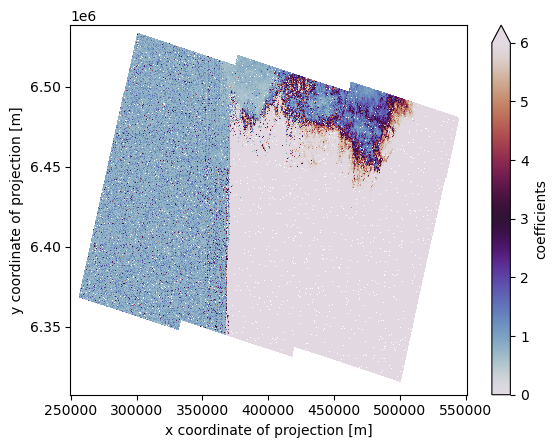

In [81]:
phase.plot.imshow(cmap='twilight', vmin=0, vmax=6)

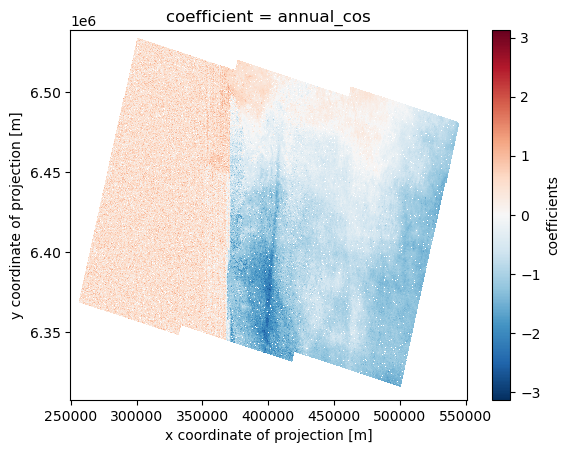

In [75]:
out.coefficients[3].plot.imshow()

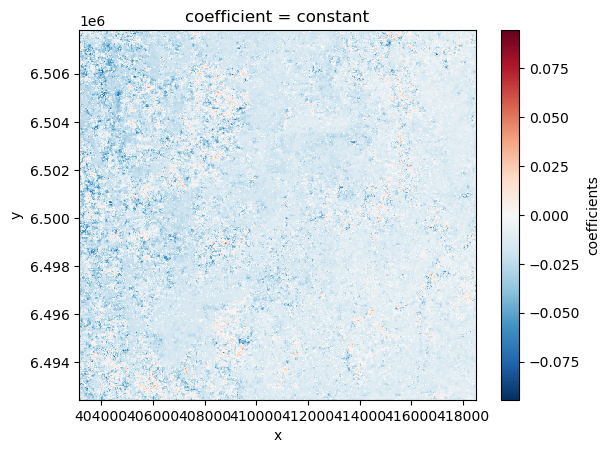

In [45]:
out.coefficients[0].plot.imshow()

In [28]:
import jax.numpy as jnp

data_jax = jnp.asarray(data_2d)
A_jax = jnp.asarray(A)

In [30]:
%%time
r1=_jax_solver.jax_solve_linear_system(A_jax, data_jax)

CPU times: user 360 ms, sys: 202 ms, total: 562 ms
Wall time: 1.53 s


In [9]:
from typing import List

from disp_xr.timeseries import lscov_2d


def create_fit_results_template(n_params: int, n_height: int, n_width: int, coeff_names: List[str]) -> xr.Dataset:
    return xr.Dataset(
        {
            "coefficients": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "standard_errors": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "z_scores": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "t_statistics": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "p_values": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "confidence_intervals_lower": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "confidence_intervals_upper": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), np.nan)),
            "is_significant": (["coefficient", "y", "x"], np.full((n_params, n_height, n_width), False, dtype=bool)),
            "mse": (["y", "x"], np.full((n_height, n_width), np.nan)),
            "n_valid": (["y", "x"], np.zeros((n_height, n_width), dtype=int)),
        },
        coords={
            "coefficient": coeff_names,
            "y": np.arange(n_height),
            "x": np.arange(n_width),
        },
        attrs={"description": "Template for time series fit results with statistical metrics."}
    )


In [10]:
from typing import Dict, List, Optional


def fit_timeseries(
    dxr: xr.DataArray,
    polynomial_degree: int = 1,
    periods: Optional[List[float]] = None,
    step_dates: Optional[List[str]] = None,
    exponential_terms: Optional[Dict[str, List[int]]] = None,
    logarithmic_terms: Optional[Dict[str, List[int]]] = None,
    reference_index: int = 0,
    confidence_level: float = 0.95,
    weights: Optional[np.ndarray] = None,
) -> xr.Dataset:
    """Fit time series data using a specified design matrix and return an xarray.Dataset
    with fitted coefficients and associated statistics.
    """
    # Generate design matrix and coefficient names
    A = create_design_matrix(
        dxr.time.values,
        polynomial_degree,
        periods,
        step_dates,
        exponential_terms,
        logarithmic_terms,
        reference_index
    )
    coeff_names = get_coefficient_names(
        polynomial_degree,
        periods,
        step_dates,
        exponential_terms,
        logarithmic_terms
    )

    # Flatten spatial dimensions
    n_time, n_height, n_width = dxr.shape
    n_params = A.shape[1]
    n_pixels = n_height * n_width
    data_2d = dxr.values.reshape(n_time, n_pixels, order='C')

    # Fit model
    results = lscov_2d(A, data_2d, weights=weights)
    stats = compute_statistics_numpy(results, confidence_level=confidence_level)

    # Reshape to spatial dims
    results = results._replace(
        coeffs=results.coeffs.reshape(n_params, n_height, n_width),
        mse=results.mse.reshape(n_height, n_width),
        n_valid=results.n_valid.reshape(n_height, n_width)
    )

    stats = stats._replace(
        coefficients=stats.coefficients.reshape(n_params, n_height, n_width),
        standard_errors=stats.standard_errors.reshape(n_params, n_height, n_width),
        z_scores=stats.z_scores.reshape(n_params, n_height, n_width),
        t_statistics=stats.t_statistics.reshape(n_params, n_height, n_width),
        p_values=stats.p_values.reshape(n_params, n_height, n_width),
        confidence_intervals_lower=stats.confidence_intervals_lower.reshape(n_params, n_height, n_width),
        confidence_intervals_upper=stats.confidence_intervals_upper.reshape(n_params, n_height, n_width),
        is_significant=stats.is_significant.reshape(n_params, n_height, n_width),
    )

    # Build xarray.Dataset
    ds = xr.Dataset(
        {
            "coefficients": (["coefficient", "y", "x"], stats.coefficients),
            "standard_errors": (["coefficient", "y", "x"], stats.standard_errors),
            "z_scores": (["coefficient", "y", "x"], stats.z_scores),
            "t_statistics": (["coefficient", "y", "x"], stats.t_statistics),
            "p_values": (["coefficient", "y", "x"], stats.p_values),
            "confidence_intervals_lower": (["coefficient", "y", "x"], stats.confidence_intervals_lower),
            "confidence_intervals_upper": (["coefficient", "y", "x"], stats.confidence_intervals_upper),
            "is_significant": (["coefficient", "y", "x"], stats.is_significant),
            "mse": (["y", "x"], results.mse),
            "n_valid": (["y", "x"], results.n_valid),
        },
        coords={
            "y": dxr.y.values if "y" in dxr.dims else np.arange(n_height),
            "x": dxr.x.values if "x" in dxr.dims else np.arange(n_width),
            "coefficient": coeff_names,
        },
        attrs={"description": "Time series fit results with statistical metrics."}
    )

    return ds

In [11]:
fitting_kwargs = {'polynomial_degree': 1,
    'periods': [1, 0.5],
    'step_dates': None,
    'exponential_terms':  None,
    'logarithmic_terms':  None}

names = get_coefficient_names(**fitting_kwargs)
n_time, n_height, n_width = ds.displacement.shape
empty_ds = create_fit_results_template(len(names), n_height, n_width, names)
empty_ds = empty_ds.chunk({'y':ds.chunks['y'], 'x':ds.chunks['x']})

In [12]:
n_time, n_height, n_width = ds.displacement.shape
empty_ds = create_fit_results_template(len(names), n_height, n_width, names)
empty_ds = empty_ds.chunk({'y':ds.chunks['y'], 'x':ds.chunks['x']})

In [13]:
out = ds.displacement.map_blocks(fit_timeseries,
                                 kwargs=fitting_kwargs, template=empty_ds)

In [ ]:
%%time
out = out.compute()

In [73]:
dd = fit_timeseries(subset)

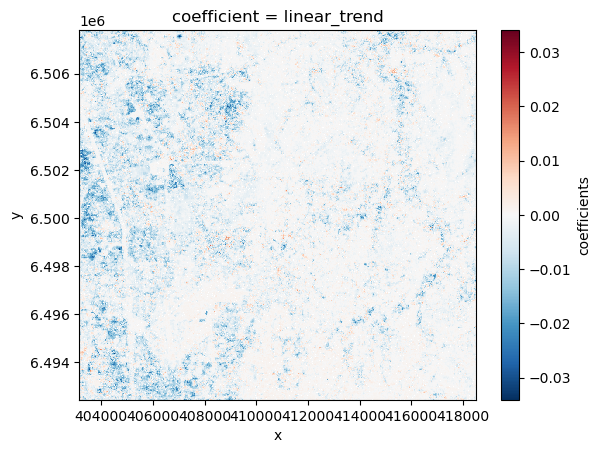

In [ ]:
out

In [ ]:
def fit_timeseries(dxr: xr.Dataarray,
                   polynomial_degree: int = 1,
                   periods: Optional[List[float]] = None,
                   step_dates: Optional[List[str]] = None,
                   exponential_terms: Optional[Dict[str, List[int]]] = None,
                   logarithmic_terms: Optional[Dict[str, List[int]]] = None,
                   reference_index: int = 0,
                   confidence_level:float = 0.95,
                   weights : Optional(np.ndarray) = None):

    # Get design matrix
    A = create_design_matrix(dxr.time.values,
                             polynomial_degree, periods,
                             step_dates, exponential_terms,
                             logarithmic_terms, reference_index)

    get_coefficient_names(polynomial_degree, periods,
                                        step_dates, exponential_terms,
                                        logarithmic_terms)

    # Get dimensions
    n_time, n_height, n_width = dxr.shape
    n_pixels = n_height * n_width

    data_2d = dxr.values.reshape(n_time, n_pixels, order='C')
    result = lscov_2d(A, data_2d, weights=weights)

    # Get residuals
    stats = compute_statistics_numpy(result, confidence_level=confidence_level)

    results._replace(coeffs=results.coeffs.reshape(n_params, n_height, n_width),
                           mse=results.mse.reshape(n_height, n_width),
                           residuals=results.residuals.reshape(n_time, n_height, n_width),
                           n_valid=results.n_valid.reshape(n_height, n_width),
                           Qxx=results.Qxx.reshape(n_params, n_params, n_height, n_width))

    stats._replace(coefficients=stats.coefficients.reshape(n_params, n_height, n_width),
                           standard_errors=stats.standard_errors.reshape(n_params, n_height, n_width),
                           z_scores=stats.z_scores.reshape(n_params, n_height, n_width),
                           t_statistics=stats.t_statistics.reshape(n_params, n_height, n_width),
                           p_values=stats.p_values.reshape(n_params, n_height, n_width),
                           confidence_intervals_lower=stats.confidence_intervals_lower.reshape(n_params, n_height, n_width),
                           confidence_intervals_upper=stats.confidence_intervals_upper.reshape(n_params, n_height, n_width),
                           is_significant = stats.is_significant.reshape(n_params, n_height, n_width),
                           correlation_matrix = stats.correlation_matrix.reshape(n_params, n_params, n_height, n_width))

    return xr.Dataset()



In [46]:
%%time
n_params = A.shape[1]
n_time, n_height, n_width = subset.shape
n_pixels = n_height * n_width
obs_2d = subset.values.reshape(n_time, n_pixels, order='C')
b = np.arange(obs_2d.shape[0])
results = lscov_2d(A, obs_2d, weights=np.ones_like(obs_2d)[:,1])

CPU times: user 22.3 s, sys: 3.8 s, total: 26.1 s
Wall time: 1.66 s


In [47]:
results1 = results._replace(coeffs=results.coeffs.reshape(n_params, n_height, n_width),
                           mse=results.mse.reshape(n_height, n_width),
                           residuals=results.residuals.reshape(n_time, n_height, n_width),
                           n_valid=results.n_valid.reshape(n_height, n_width),
                           Qxx=results.Qxx.reshape(n_params, n_params, n_height, n_width))

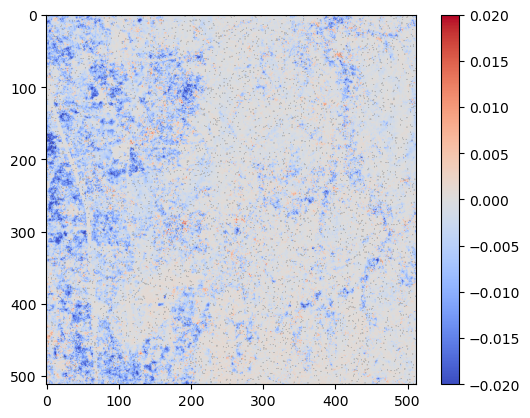

In [43]:
from matplotlib import pyplot as plt

plt.imshow(results.coeffs[1], cmap='coolwarm', clim=[-0.02 ,0.02])
plt.colorbar()

(6, 6, 262144)

In [66]:
stats = compute_statistics_numpy(result=results, confidence_level=0.95)

stats1 = stats._replace(coefficients=stats.coefficients.reshape(n_params, n_height, n_width),
                           standard_errors=stats.standard_errors.reshape(n_params, n_height, n_width),
                           z_scores=stats.z_scores.reshape(n_params, n_height, n_width),
                           t_statistics=stats.t_statistics.reshape(n_params, n_height, n_width),
                           p_values=stats.p_values.reshape(n_params, n_height, n_width),
                           confidence_intervals_lower=stats.confidence_intervals_lower.reshape(n_params, n_height, n_width),
                           confidence_intervals_upper=stats.confidence_intervals_upper.reshape(n_params, n_height, n_width),
                           is_significant = stats.is_significant.reshape(n_params, n_height, n_width),
                           correlation_matrix = stats.correlation_matrix.reshape(n_params, n_params, n_height, n_width))

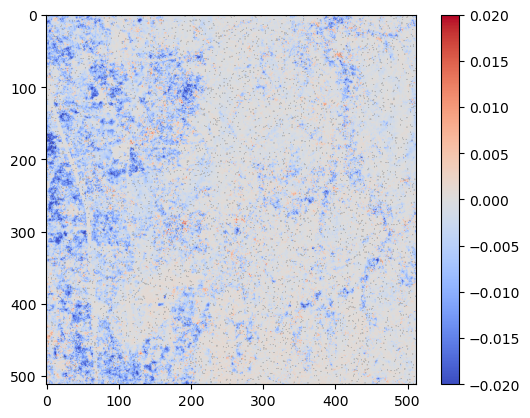

In [67]:
plt.imshow(stats1.coefficients[1], cmap='coolwarm', clim=[-0.02 ,0.02])
plt.colorbar()

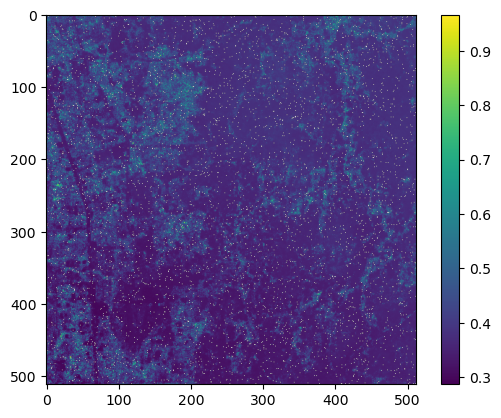

In [58]:
plt.imshow(stats1.standard_errors[1]*1e3)
plt.colorbar()

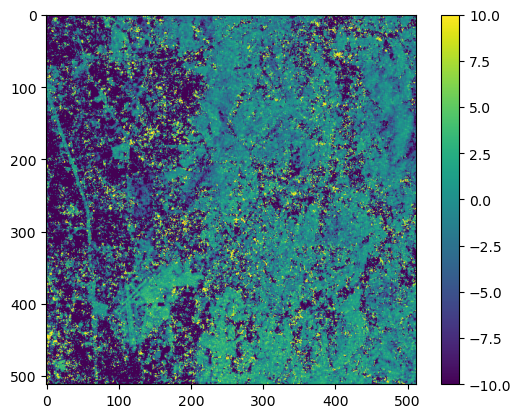

In [59]:
plt.imshow(stats1.z_scores[1], clim=[-10,10])
plt.colorbar()

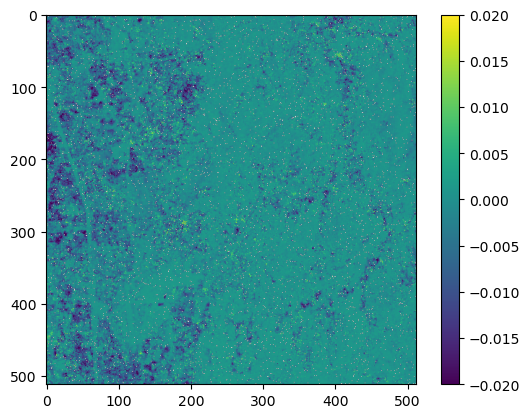

In [63]:
plt.imshow(stats1.confidence_intervals_upper[1], clim=[-0.02,0.02])
plt.colorbar()

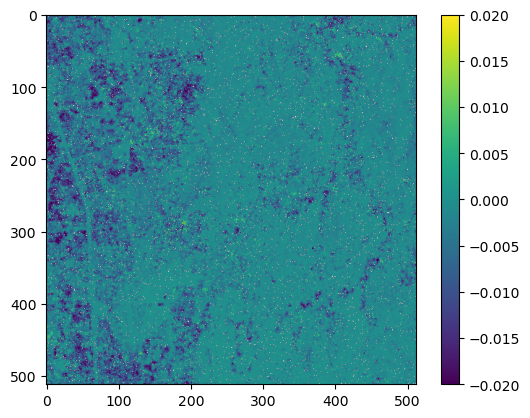

In [64]:
plt.imshow(stats1.confidence_intervals_lower[1], clim=[-0.02,0.02])
plt.colorbar()

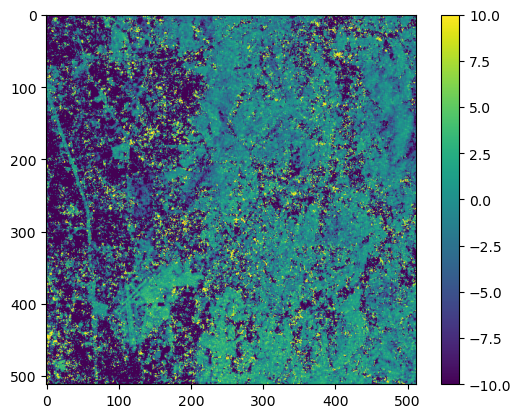

In [61]:

plt.imshow(stats1.t_statistics[1], clim=[-10,10])
plt.colorbar()

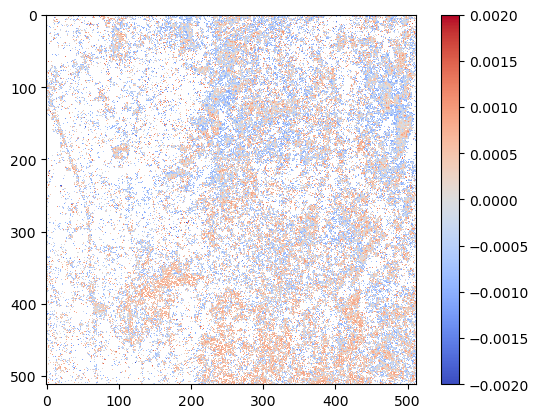

In [17]:
mask = stats.is_significant[1].reshape(n_height, n_width)
plt.imshow(np.ma.masked_array(stats.coefficients[1].reshape(n_height, n_width), mask=np.abs(stats.t_statistics[1].reshape(n_height, n_width))>3), cmap='coolwarm', clim=[-0.002 ,0.002], interpolation='nearest')
plt.colorbar()

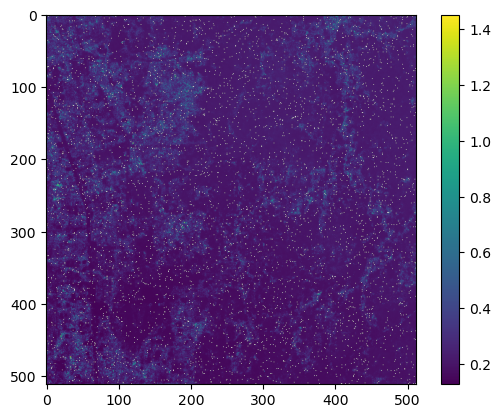

In [92]:
plt.imshow(results.mse.reshape(n_height, n_width)*1e3)
plt.colorbar()

In [19]:
import jax

from disp_xr.timeseries import _jax_solver, jax_solve_linear_system

In [20]:
%%time
rp = jax_solve_linear_system(A_jax, data_jax)

CPU times: user 318 ms, sys: 84.6 ms, total: 403 ms
Wall time: 1.04 s


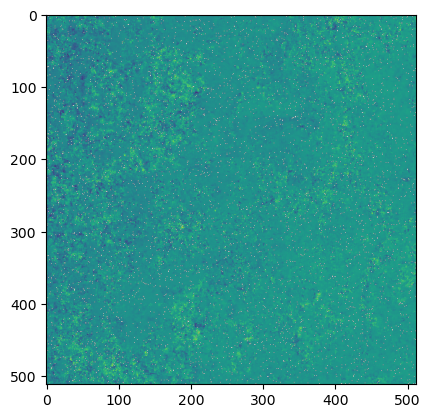

In [21]:
plt.imshow(rp[0][0].reshape(n_height, n_width))

In [22]:
%%time
rr = _jax_solver.fit_timeseries_2d_jax(A_jax, data_jax)

CPU times: user 521 ms, sys: 59 ms, total: 580 ms
Wall time: 165 ms


In [26]:
data_jax.shape

(254, 262144)

In [27]:
rr

: 

: 

: 

In [ ]:
def fit_fn(pixel):
    return fit_timeseries_pixelwise_jax(A_jax, pixel, None, 5)

In [151]:
@jax.jit
def _solve_with_missing_data_jax(
    A: jnp.ndarray,
    b: jnp.ndarray,
    weights: Optional[jnp.ndarray] = None,
    min_obs: int = 5
) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Solve linear system with missing data and return full statistics.

    Parameters
    ----------
    A : jnp.ndarray
        Design matrix (n_obs, n_params)
    b : jnp.ndarray
        Observations (n_obs,) - may contain NaN
    weights : jnp.ndarray, optional
        Observation weights (n_obs,)
    min_obs : int
        Minimum number of valid observations

    Returns
    -------
    x : jnp.ndarray
        Solution (n_params,)
    mse : float
        Mean squared error
    Qxx : jnp.ndarray
        Covariance matrix (n_params, n_params)
    residuals : jnp.ndarray
        Residuals (n_obs,)
    n_valid : int
        Number of valid observations used
    rank : int
        Effective rank of design matrix

    """
    n_obs, n_params = A.shape
    n_pixels = b.shape[0]

    # Create validity mask
    valid_mask = ~jnp.isnan(b)
    n_valid = jnp.sum(valid_mask)

    # Replace NaN values with zeros
    b_clean = jnp.atleast_2d(jnp.where(valid_mask, b, 0.0))

    # Create effective weights
    if weights is None:
        eff_weights = valid_mask.astype(jnp.float32)
    else:
        eff_weights = jnp.where(valid_mask, weights, 0.0)

    def solve_case():
        x, mse, Qxx, residuals, rank = jax_solve_linear_system(A, b_clean, eff_weights)
        # Mask residuals for invalid observations
        masked_residuals = jnp.where(valid_mask, residuals, jnp.nan)
        return x, mse, Qxx, masked_residuals, n_valid, rank

    def insufficient_data_case():
        nan_coeffs = jnp.full((n_params, n_pixels), jnp.nan)
        nan_mse = jnp.full((n_pixels,), jnp.nan)
        nan_Qxx = jnp.full((n_params, n_params, n_pixels), jnp.nan)
        nan_residuals = jnp.full((n_obs, n_pixels), jnp.nan)
        zero_rank = jnp.array(0)
        return nan_coeffs, nan_mse, nan_Qxx, nan_residuals, n_valid, zero_rank

    return lax.cond(n_valid >= min_obs, solve_case, insufficient_data_case)

In [119]:
n_obs, n_params = A_jax.shape

b = data_2d[:,1]

# Create validity mask
valid_mask = ~jnp.isnan(b)
n_valid = jnp.sum(valid_mask)

# Replace NaN values with zeros
b_clean = jnp.where(valid_mask, b, 0.0)

eff_weights = valid_mask.astype(jnp.float32)

x, mse, Qxx, residuals, rank = jax_solve_linear_system(A, b_clean, eff_weights)

IndexError: Too many indices: 0-dimensional array indexed with 1 regular index.

In [128]:
results = jax.vmap(fit_fn, in_axes=1, out_axes=(1, 0, 2, 1, 0, 0))(data_2d)

TypeError: cond branches must have equal output types but they differ.

true_fun is solve_case at /tmp/ipykernel_133559/1073245696.py:52
false_fun is insufficient_data_case at /tmp/ipykernel_133559/1073245696.py:58

  * the output of true_fun at path [0] has type float32[6,254] but the corresponding output of false_fun has type float32[6], so the shapes do not match;
  * the output of true_fun at path [1] has type float32[254] but the corresponding output of false_fun has type float32[], so the shapes do not match;
  * the output of true_fun at path [2] has type float32[6,6,254] but the corresponding output of false_fun has type float32[6,6], so the shapes do not match;
  * the output of true_fun at path [3] has type float32[254,254] but the corresponding output of false_fun has type float32[254], so the shapes do not match.

Revise true_fun and/or false_fun so that all output types match.

In [156]:
data_2d = data_jax.reshape(n_time, n_height * n_width)

coeefs = fit_timeseries_2d_jax(A_jax, data_2d, jnp.ones_like(data_2d))


In [157]:
data_2d

: 

: 

: 

NameError: name 'data_2d' is not defined

In [58]:
tol: float = 1e-10
n_obs, n_params = A_jax.shape
n_pixels = data_jax.shape[1]

weights = jnp.atleast_2d(jnp.ones_like(n_obs))
sqrt_weights = jnp.sqrt(jnp.maximum(weights, 0.0))
A_weighted = jnp.squeeze(A_jax * sqrt_weights[:, None])
b_weighted = (data_jax.T * sqrt_weights).T

# QR decomposition with error handling
#try:
#    Q, R = jnp.linalg.qr(A_weighted, mode='reduced')
#except Exception:
# Fallback to pseudo-inverse
A_pinv = jnp.linalg.pinv(A_weighted)
x = A_pinv @ b_weighted
residuals_weighted = b_weighted - A_weighted @ x
residuals = residuals_weighted / jnp.maximum(sqrt_weights, tol)

In [59]:
b_weighted.shape

(254, 262144)

In [60]:
n_effective = jnp.nansum(weights)
mse = jnp.nansum(residuals_weighted**2) / jnp.maximum(1.0, n_effective - n_params)
Qxx_base = A_pinv @ A_pinv.T
rank = jnp.linalg.matrix_rank(A_weighted, tol=tol)

In [ ]:
%%time
tol: float = 1e-10
n_obs, n_params = A_jax.shape
n_pixels = data_jax.shape[1]

weights = jnp.atleast_2d(jnp.ones_like(n_obs))
sqrt_weights = jnp.sqrt(jnp.maximum(weights, 0.0))
A_weighted = jnp.squeeze(A_jax * sqrt_weights[:, None])
b_weighted = (data_jax.T * sqrt_weights).T

# QR decomposition with error handling

try:
    Q, R = jnp.linalg.qr(A_weighted, mode='reduced')

    # Standard QR solution
    z = Q.T @ b_weighted

    #  Rank computation
    r_diag = jnp.abs(jnp.diag(R))
    rank_tol = tol * jnp.maximum(r_diag[0], tol)
    rank = jnp.sum(r_diag > rank_tol)

    # Solve with regularization for ill-conditioned systems
    R_reg = R + jnp.eye(n_params) * tol
    x = jax.scipy.linalg.solve_triangular(R_reg, z)

    # Compute residuals and statistics
    fitted_weighted = Q @ z
    residuals_weighted = b_weighted - fitted_weighted
    residuals = residuals_weighted / jnp.atleast_2d(jnp.maximum(sqrt_weights, tol)).T

    n_effective = jnp.nansum(weights)
    dof = jnp.maximum(1.0, n_effective - rank)
    mse = jnp.nansum(residuals_weighted**2, axis=0) / dof

    try:
        R_inv = jax.scipy.linalg.solve_triangular(R, jnp.eye(n_params))
        Qxx_base = (R_inv @ R_inv.T)
    except Exception:
        # Fallback using pseudo-inverse
        R_pinv = jnp.linalg.pinv(R)
        Qxx_base = R_pinv @ R_pinv.T

    # Expand covariance matrix
    Qxx = mse[None, None, :] * Qxx_base[:, :, None]

except Exception:
    # Fallback to pseudo-inverse
    A_pinv = jnp.linalg.pinv(A_weighted)
    x = A_pinv @ b_weighted
    residuals_weighted = b_weighted - A_weighted @ x
    residuals = residuals_weighted / jnp.atleast_2d(jnp.maximum(sqrt_weights, tol)).T

    n_effective = jnp.nansum(weights)
    mse = jnp.nansum(residuals_weighted**2, axis=0) / jnp.maximum(1.0, n_effective - n_params)
    Qxx_base = A_pinv @ A_pinv.T
    rank = jnp.linalg.matrix_rank(A_weighted, tol=tol)
    Qxx = mse[None, None, :] * Qxx_base[:, :, None]

CPU times: user 2.75 s, sys: 1.05 s, total: 3.81 s
Wall time: 393 ms


In [ ]:
%%time
tol: float = 1e-10
n_obs, n_params = A_jax.shape
n_pixels = data_jax.shape[1]

weights = jnp.atleast_2d(jnp.ones_like(n_obs))
sqrt_weights = jnp.sqrt(jnp.maximum(weights, 0.0))
A_weighted = jnp.squeeze(A_jax * sqrt_weights[:, None])
b_weighted = (data_jax.T * sqrt_weights).T


# Fallback to pseudo-inverse
A_pinv = jnp.linalg.pinv(A_weighted)
x = A_pinv @ b_weighted
residuals_weighted = b_weighted - A_weighted @ x
residuals = residuals_weighted / jnp.maximum(sqrt_weights, tol).T

n_effective = jnp.nansum(weights)
mse = jnp.nansum(residuals_weighted**2, axis=0) / jnp.maximum(1.0, n_effective - n_params)
Qxx_base = A_pinv @ A_pinv.T
rank = jnp.linalg.matrix_rank(A_weighted, tol=tol)
Qxx = mse[None, None, :] * Qxx_base[:, :, None]

CPU times: user 470 ms, sys: 2.33 s, total: 2.8 s
Wall time: 283 ms


In [79]:
residuals.shape

(254, 262144)

In [63]:
Qxx.shape

(6, 6, 262144)

In [56]:
R_inv.shape

(6, 6)

In [27]:
Q, R = jnp.linalg.qr(A_weighted, mode='reduced')

In [28]:
z = Q.T @ b_weighted

# Enhanced rank computation
r_diag = jnp.abs(jnp.diag(R))
rank_tol = tol * jnp.maximum(r_diag[0], tol)
rank = jnp.sum(r_diag > rank_tol)

# Solve with regularization for ill-conditioned systems
R_reg = R + jnp.eye(n_params) * tol
x = jax.scipy.linalg.solve_triangular(R_reg, z)

In [38]:
# Compute residuals and statistics
fitted_weighted = Q @ z
residuals_weighted = b_weighted - fitted_weighted
residuals = residuals_weighted / jnp.atleast_2d(jnp.maximum(sqrt_weights, tol)).T

In [39]:
residuals.shape

(254, 262144)

In [35]:
(jnp.maximum(sqrt_weights, tol)).shape

(254,)

In [35]:

# Enhanced rank computation
r_diag = jnp.abs(jnp.diag(R))
rank_tol = tol * jnp.maximum(r_diag[0], tol)
rank = jnp.sum(r_diag > rank_tol)

# Solve with regularization for ill-conditioned systems
R_reg = R + jnp.eye(n_params) * tol
x = jax.scipy.linalg.solve_triangular(R_reg, z)

In [36]:
# Compute residuals and statistics
fitted_weighted = Q @ z
residuals_weighted = data_jax - fitted_weighted
residuals = residuals_weighted / jnp.maximum(sqrt_weights, tol)

n_effective = jnp.sum(weights)
dof = jnp.maximum(1.0, n_effective - rank)
mse = jnp.sum(residuals_weighted**2) / dof

# Enhanced covariance computation
try:
    R_inv = jax.scipy.linalg.solve_triangular(R, jnp.eye(n_params))
    Qxx = mse * (R_inv @ R_inv.T)
except Exception:
    # Fallback using pseudo-inverse
    R_pinv = jnp.linalg.pinv(R)
    Qxx = mse * (R_pinv @ R_pinv.T)

Array([[-1.7206907e-02, -1.8171778e-02, -1.3591449e-02, ...,
        -1.6001593e-02, -1.4288154e-02,            nan],
       [-5.3828331e-03, -4.2008064e-03,  1.1903378e-03, ...,
         9.1209344e-04, -8.4060163e-04,            nan],
       [-2.0311340e-03, -3.2671345e-03, -3.3507831e-03, ...,
        -2.9861364e-03, -3.0590699e-03,            nan],
       [-1.0886722e-03, -1.8547098e-03, -2.0458787e-03, ...,
         4.7273166e-03,  4.5363647e-03,            nan],
       [ 1.5166416e-03,  2.3372415e-03,  3.0726846e-03, ...,
        -2.9212684e-05,  4.8262220e-05,            nan],
       [ 1.2474445e-03,  1.1412617e-03,  6.6368829e-04, ...,
         1.6463773e-03,  1.5256261e-03,            nan]], dtype=float32)

In [33]:
%%time
result2 = _solve_linear_system(A_jax, data_jax, jnp.ones_like(data_jax))

ValueError: Incompatible shapes for broadcasting: shapes=[(254, 6), (254, 1, 262144)]

In [ ]:
result2

(Array([[-1.7206907e-02, -1.8171778e-02, -1.3591449e-02, ...,
         -1.6001593e-02, -1.4288154e-02,            nan],
        [-5.3828331e-03, -4.2008064e-03,  1.1903378e-03, ...,
          9.1209344e-04, -8.4060163e-04,            nan],
        [-2.0311340e-03, -3.2671345e-03, -3.3507831e-03, ...,
         -2.9861364e-03, -3.0590699e-03,            nan],
        [-1.0886722e-03, -1.8547098e-03, -2.0458787e-03, ...,
          4.7273166e-03,  4.5363647e-03,            nan],
        [ 1.5166416e-03,  2.3372415e-03,  3.0726846e-03, ...,
         -2.9212684e-05,  4.8262220e-05,            nan],
        [ 1.2474445e-03,  1.1412617e-03,  6.6368829e-04, ...,
          1.6463773e-03,  1.5256261e-03,            nan]], dtype=float32),
 Array(nan, dtype=float32),
 Array([[nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, n

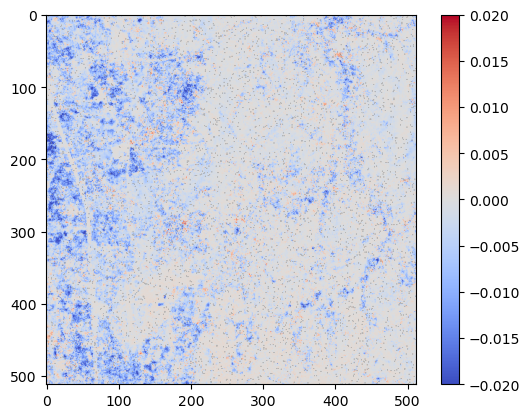

In [31]:
from matplotlib import pyplot as plt

plt.imshow(result2[0][1].reshape(n_height, n_width), cmap='coolwarm', clim=[-0.02 ,0.02])
plt.colorbar()